In [1]:
import pystac
from datetime import datetime
import rasterio
import rasterio.warp

In [5]:
import sys
from pathlib import Path
# Add the src directory to sys.path
sys.path.append(str(Path().resolve().parents[0] / "src"))

In [6]:
from datasource.chelsa import s3

# Single STAC

## STAC generation

In [16]:
test_url = s3.format_url_month_ts("pr", 1, 2000)
print(test_url)  

https://os.unil.cloud.switch.ch/chelsa02/chelsa/global/monthly/pr/2000/CHELSA_pr_01_2000_V.2.1.tif


In [17]:
src.bounds

BoundingBox(left=-180.00013888885002, bottom=-90.00013888885, right=179.99985967115003, top=83.99986041515)

In [24]:
def generate_stac_item(url, stac_id, dt, band_id, band_title, output_path):
    if isinstance(dt, str):
        # Parses "YYYY-MM-DD" strings into datetime objects
        dt = datetime.strptime(dt, "%Y-%m-%d")
    with rasterio.open(url) as src:
        # Automate Media Type using Rasterio Driver ---
        driver = src.driver
        media_type = "application/octet-stream" # Default
        if driver == 'GTiff':
            # Check if it is likely Cloud Optimized (Tiled + Compressed)
            # This distinguishes a basic TIFF from a COG
            if src.profile.get('tiled') and src.profile.get('compress'):
                 media_type = pystac.MediaType.COG
            else:
                 media_type = pystac.MediaType.GEOTIFF          
        elif driver in ['JP2OpenJPEG', 'JPEG2000']:
            media_type = pystac.MediaType.JPEG2000
        elif driver == 'netCDF':
            media_type = "application/x-netcdf"   
        elif driver in ['HDF4', 'HDF5', 'HDF4Image', 'HDF5Image']:
            media_type = "application/x-hdf"     
        elif driver == 'PNG':
            media_type = pystac.MediaType.PNG    
        elif driver == 'JPEG':
            media_type = pystac.MediaType.JPEG
        """
        STAC catalogue are searchable and discoverable spatially speaking in terms of longitude and latitude
            - proj_bounds saves the coordinates of the file in its native CRS
            - left, bottom, right, top saves the coordinates in lat/lon for searchability and discoverability
        """
        proj_bounds = list(src.bounds)
        #Transform bounds from src_crs to dst_crs (4326).
        left, bottom, right, top = rasterio.warp.transform_bounds(src.crs, "EPSG:4326", *src.bounds)
        item = pystac.Item(id=stac_id,
                           geometry={"type":"Polygon",
                                     "coordinates": [[[left, bottom],
                                                    [right, bottom],
                                                    [right, top],
                                                    [left, top],
                                                    [left, bottom]
                                                ]]},
                           bbox=[left, bottom, right, top],
                           datetime=dt,
                           # Caveat ("proj:shape"): this is [height, width] and not [width, height] if you want to set them yourself
                           properties={"proj:epsg": src.crs.to_epsg(),
                                       "proj:shape": src.shape,
                                       "proj:bbox": proj_bounds,},
                           stac_extensions=["https://stac-extensions.github.io/eo/v1.1.0/schema.json",
                                            "https://stac-extensions.github.io/projection/v1.1.0/schema.json",],
                           assets={band_id: pystac.Asset(href=url,
                                                         title=band_title,
                                                         media_type=media_type,
                                                         roles=["data"],
                                                         # REQUIRED: define the bands in the eo extension for openEO to be able to load it
                                                         extra_fields={"eo:bands": [{"name": band_id,}],})})
        item.validate()
        # Include self link will reference absolute local path. We need it to be discoverable for the backend
        item.save_object(dest_href=output_path, include_self_link=False)

In [25]:
generate_stac_item(test_url, "CHELSAmonthly_pr_01012000", "2000-01-10", "pr", "pr 01/01/2000 CHELSA", "testSTAC.json")

## Importing external STAC into openEO

In [28]:
import pystac

chelsa_stac_url = "https://raw.githubusercontent.com/nbillietPM/BmC/refs/heads/openEO/scripts/testSTAC.json"

item = pystac.Item.from_file(chelsa_stac_url)

print(f"ID: {item.id}")
print(f"Date: {item.datetime}")

# 2. Access the Assets
# Assets are stored in a dictionary keyed by the name you gave them (e.g., 'pr', 'data', or band_id)
assets = item.assets

print("\nAvailable Assets:")
for key, asset in assets.items():
    print(f"- Key: {key}")
    print(f"  Href: {asset.href}")
    print(f"  Media Type: {asset.media_type}")
    
# 3. Get a specific asset URL
if "pr" in assets:
    download_url = assets["pr"].href
    print(f"\nDownload URL for 'pr': {download_url}")

ID: CHELSAmonthly_pr_01012000
Date: 2000-01-10 00:00:00+00:00

Available Assets:
- Key: pr
  Href: https://os.unil.cloud.switch.ch/chelsa02/chelsa/global/monthly/pr/2000/CHELSA_pr_01_2000_V.2.1.tif
  Media Type: image/tiff; application=geotiff; profile=cloud-optimized

Download URL for 'pr': https://os.unil.cloud.switch.ch/chelsa02/chelsa/global/monthly/pr/2000/CHELSA_pr_01_2000_V.2.1.tif


In [33]:
import openeo

connection = openeo.connect("https://openeo.dataspace.copernicus.eu")
connection.authenticate_oidc()

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

In [34]:
# 3. Load it into a Data Cube
datacube = connection.load_stac(
    url=chelsa_stac_url,
    
    # Optional: Filter spatial/temporal bounds immediately
    # If your STAC Item has specific bounds, openEO usually reads them automatically.
    # But explicitly setting them is safer if you want a subset.
    spatial_extent={"west": -10, "south": 35, "east": 30, "north": 70},
    temporal_extent=["2000-01-01", "2000-01-31"],
    
    # Optional: Select bands (uses the "name" from your 'eo:bands' metadata)
    bands=["pr"]
)
datacube

In [35]:
output_cube = datacube.save_result(format="netCDF")

# 2. Create a Job on the server
job = output_cube.create_job(
    title="CHELSA precipitation 01/01/2000",
    description="Testing external STAC"
)

# 3. Start the job and wait for it to finish
# This might take minutes or hours depending on the size
print(f"Job {job.job_id} started...")
job.start_and_wait()

# 4. Download the files once finished
results = job.get_results()
results.download_files("./testSTAC_download")
print("Download complete!")

Job j-260209122227423db2f24416e64429da started...
0:00:00 Job 'j-260209122227423db2f24416e64429da': send 'start'
0:00:20 Job 'j-260209122227423db2f24416e64429da': created (progress 0%)
0:00:25 Job 'j-260209122227423db2f24416e64429da': created (progress 0%)
0:00:32 Job 'j-260209122227423db2f24416e64429da': created (progress 0%)
0:00:40 Job 'j-260209122227423db2f24416e64429da': running (progress N/A)
0:00:50 Job 'j-260209122227423db2f24416e64429da': running (progress N/A)
0:01:02 Job 'j-260209122227423db2f24416e64429da': running (progress N/A)
0:01:18 Job 'j-260209122227423db2f24416e64429da': running (progress N/A)
0:01:37 Job 'j-260209122227423db2f24416e64429da': running (progress N/A)
0:02:01 Job 'j-260209122227423db2f24416e64429da': running (progress N/A)
0:02:31 Job 'j-260209122227423db2f24416e64429da': running (progress N/A)
0:03:09 Job 'j-260209122227423db2f24416e64429da': finished (progress 100%)
Download complete!


In [37]:
ls "testSTAC_download/"

 Volume in drive C is OS
 Volume Serial Number is 1C25-B250

 Directory of C:\Users\niels\Documents\Repositories\BmC\scripts\testSTAC_download

09/02/2026  13:25    <DIR>          .
09/02/2026  13:26    <DIR>          ..
09/02/2026  13:25             4.419 job-results.json
09/02/2026  13:25         4.740.399 openEO.nc
               2 File(s)      4.744.818 bytes
               2 Dir(s)  225.099.546.624 bytes free


In [ ]:
West (Min X): You have -9.995973. This is effectively -10.

East (Max X): You have 30.004027. This is effectively 30.

North (Max Y): You have 70.004027. This is effectively 70.

South (Min Y): You have 35.004027. This is effectively 35.

In [46]:
import xarray as xr
import numpy as np

ds = xr.open_dataset("testSTAC_download/openEO.nc")

# 1. Get the Bounds
min_x = ds.x.min().item()
max_x = ds.x.max().item()
min_y = ds.y.min().item()
max_y = ds.y.max().item()

# 2. Calculate Pixel Resolution (The size of one cell)
# We take the difference between the first two pixels
pixel_res_x = abs(ds.x[1] - ds.x[0]).item()
pixel_res_y = abs(ds.y[1] - ds.y[0]).item()

print(f"Pixel Resolution: ~{pixel_res_x:.5f} degrees")
print(f"Result Bounds: {min_x:.4f}, {min_y:.4f}, {max_x:.4f}, {max_y:.4f}")

# 3. Verification Logic with Tolerance
# We allow the result to be outside by up to 1 full pixel size to account for overlaps
tolerance_x = pixel_res_x * 1.0
tolerance_y = pixel_res_y * 1.0

# Check West (Allow it to be slightly smaller than -10)
assert -10 - tolerance_x <= min_x <= -10 + tolerance_x, f"West bound mismatch! Got {min_x}"

# Check East (Allow it to be slightly larger than 30)
assert 30 - tolerance_x <= max_x <= 30 + tolerance_x, f"East bound mismatch! Got {max_x}"

# Check South
assert 35 - tolerance_y <= min_y <= 35 + tolerance_y, f"South bound mismatch! Got {min_y}"

# Check North
assert 70 - tolerance_y <= max_y <= 70 + tolerance_y, f"North bound mismatch! Got {max_y}"

print("✅ Verification Successful: Bounds match within pixel tolerance.")

Pixel Resolution: ~0.00833 degrees
Result Bounds: -9.9960, 35.0040, 30.0040, 70.0040
✅ Verification Successful: Bounds match within pixel tolerance.


In [43]:
ds

<xarray.Dataset> Size: 81MB
Dimensions:  (t: 1, x: 4801, y: 4201)
Coordinates:
  * t        (t) datetime64[ns] 8B 2000-01-10
  * x        (x) float64 38kB -9.996 -9.988 -9.979 -9.971 ... 29.99 30.0 30.0
  * y        (y) float64 34kB 70.0 70.0 69.99 69.98 ... 35.03 35.02 35.01 35.0
Data variables:
    crs      |S1 1B ...
    pr       (t, y, x) float32 81MB ...
Attributes:
    Conventions:  CF-1.9
    institution:  Copernicus Data Space Ecosystem openEO API - 0.71.0a9.dev20...
    description:  
    title:

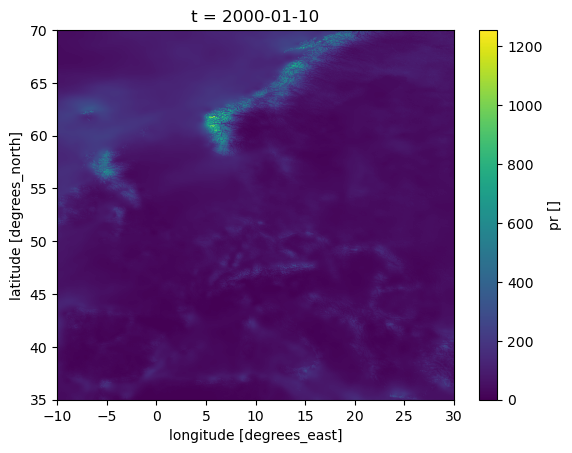

In [40]:
import matplotlib.pyplot as plt

ds["pr"].plot()

## External confirmation via rasterio

In [49]:
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
import xarray as xr
import numpy as np

# --- 1. Load the OpenEO Result ---
# This is the file you downloaded from the openEO job
ds_openeo = xr.open_dataset("testSTAC_download/openEO.nc")

# Select the first time step to get a 2D array (y, x)
openeo_arr = ds_openeo['pr'].isel(t=0).values

# --- 2. Calculate Exact Sampling Bounds ---
# OpenEO/Xarray coordinates represent pixel CENTERS. 
# Rasterio needs pixel EDGES. We must convert them.

# A. Get Resolution (Distance between two pixels)
res_x = abs(ds_openeo.x[1] - ds_openeo.x[0]).item()
res_y = abs(ds_openeo.y[1] - ds_openeo.y[0]).item()

# B. Calculate Edges (Center +/- Half Resolution)
min_x = ds_openeo.x.min().item() - (res_x / 2)
max_x = ds_openeo.x.max().item() + (res_x / 2)
min_y = ds_openeo.y.min().item() - (res_y / 2)
max_y = ds_openeo.y.max().item() + (res_y / 2)

print(f"OpenEO Grid Edges: West={min_x:.4f}, South={min_y:.4f}, East={max_x:.4f}, North={max_y:.4f}")

# --- 3. Sample the Original File (test_url) ---
# We use the variable 'test_url' as requested
print(f"Sampling source file: {test_url}")

with rasterio.open(test_url) as src:
    
    # A. Create a Window 
    # This identifies exactly which rows/cols in the giant TIFF correspond to our bounds
    window = from_bounds(min_x, min_y, max_x, max_y, transform=src.transform)
    
    # B. Read the Data
    # boundless=True handles cases where the window might slightly hang off the edge due to rounding
    source_arr = src.read(1, window=window, boundless=True)
    
    # C. Handle Nodata
    # Convert the TIFF's specific nodata value (e.g., -32768) to NaN to match OpenEO
    if src.nodata is not None:
        source_arr = source_arr.astype('float32') # Ensure we can hold NaNs
        source_arr[source_arr == src.nodata] = np.nan

# --- 4. Align Shapes ---
# Floating point rounding might cause the window read to be 1 pixel larger/smaller.
# We crop both arrays to the minimum common size to ensure overlap.
rows = min(openeo_arr.shape[0], source_arr.shape[0])
cols = min(openeo_arr.shape[1], source_arr.shape[1])

arr_openeo_crop = openeo_arr[:rows, :cols]
arr_source_crop = source_arr[:rows, :cols]

print(f"Comparing overlap shape: {arr_openeo_crop.shape}")

# --- 5. Run Comparison ---
# equal_nan=True ensures that NaN == NaN returns True
# rtol=1e-5 allows for tiny floating point differences (compression artifacts)
is_match = np.allclose(arr_openeo_crop, arr_source_crop, rtol=1e-05, equal_nan=True)

if is_match:
    print("\n✅ SUCCESS: The literal pixel values match perfectly!")
else:
    # Calculate stats on the difference
    diff = np.abs(arr_openeo_crop - arr_source_crop)
    max_diff = np.nanmax(diff)
    print(f"\n❌ MISMATCH: Values differ.")
    print(f"   Max Difference: {max_diff}")
    print(f"   Mean Difference: {np.nanmean(diff)}")
    
    # Inspect a small sample
    print("\nSample Mismatch (OpenEO vs Source):")
    print(arr_openeo_crop[0:5, 0:5])
    print("vs")
    print(arr_source_crop[0:5, 0:5])

OpenEO Grid Edges: West=-10.0001, South=34.9999, East=30.0082, North=70.0082
Sampling source file: https://os.unil.cloud.switch.ch/chelsa02/chelsa/global/monthly/pr/2000/CHELSA_pr_01_2000_V.2.1.tif
Comparing overlap shape: (4201, 4801)

✅ SUCCESS: The literal pixel values match perfectly!


# Additional code blocks for future 

In [ ]:
### Multi band tiff file

# Inside your pystac.Item definition...
assets={
    "visual": pystac.Asset(  # One key for the whole file
        href=tiff_url,
        title="RGB Image",
        roles=["data", "visual"],
        extra_fields={
            "eo:bands": [
                {
                    "name": "red",          # Band 1 in the Tiff
                    "common_name": "red",   # Optional: Helps clients find "red" automatically
                    "description": "Band 1 - Red Channel"
                },
                {
                    "name": "green",        # Band 2 in the Tiff
                    "common_name": "green",
                    "description": "Band 2 - Green Channel"
                },
                {
                    "name": "blue",         # Band 3 in the Tiff
                    "common_name": "blue",
                    "description": "Band 3 - Blue Channel"
                }
            ]
        }
    )
}

### Multiband multi tiff files

# distinct file paths
red_url = "path/to/image_red.tif"
nir_url = "path/to/image_nir.tif"

assets={
    "red": pystac.Asset(
        href=red_url,
        title="Red Band",
        roles=["data"],
        extra_fields={
            "eo:bands": [{
                "name": "B04",          # The specific ID
                "common_name": "red"    # The standard alias
            }]
        }
    ),
    "nir": pystac.Asset(
        href=nir_url,
        title="NIR Band",
        roles=["data"],
        extra_fields={
            "eo:bands": [{
                "name": "B08",
                "common_name": "nir"
            }]
        }
    )
}

### Tiled tiff files

import pystac
from pystac import CatalogType
import rasterio
from rasterio.warp import transform_bounds
from datetime import datetime
import os

# 1. Create the Collection (The Dataset Container)
collection = pystac.Collection(
    id="clc-plus-timeseries",
    title="Corine Land Cover Plus - Time Series",
    description="Monthly Land Cover classification from 2018-2020.",
    extent=pystac.Extent(
        spatial=pystac.SpatialExtent([[-180, -90, 180, 90]]),  # Placeholder
        temporal=pystac.TemporalExtent([[datetime.now(), datetime.now()]]) # Placeholder
    ),
    stac_extensions=[
        "https://stac-extensions.github.io/eo/v1.1.0/schema.json",
        "https://stac-extensions.github.io/projection/v1.1.0/schema.json"
    ]
)

# Imagine a list of file paths (could be different times OR different tiles)
file_list = [
    "data/CLC_2018_01_Tile1.tif",
    "data/CLC_2018_02_Tile1.tif", 
    "data/CLC_2018_01_Tile2.tif"
]

items = []

for file_path in file_list:
    with rasterio.open(file_path) as src:
        # --- A. Spatial Extraction (Handles Tiles) ---
        # Each tile gets its own unique BBOX
        proj_bounds = list(src.bounds)
        proj_epsg = src.crs.to_epsg()
        left, bottom, right, top = transform_bounds(src.crs, "EPSG:4326", *src.bounds)
        bbox = [left, bottom, right, top]
        
        geometry = {
            "type": "Polygon",
            "coordinates": [[[left, bottom], [right, bottom], [right, top], [left, top], [left, bottom]]]
        }

        # --- B. Temporal Extraction (Handles Time Steps) ---
        # Strategy 1: Parse filename (e.g., 'CLC_2018_01...')
        # date_str = os.path.basename(file_path).split('_')[1:3] 
        # item_date = datetime(int(date_str[0]), int(date_str[1]), 1)
        
        # Strategy 2: Read internal metadata (if available)
        # item_date = datetime.strptime(src.tags()['TIFFTAG_DATETIME'], '%Y:%m:%d %H:%M:%S')

        # Fallback for this example
        item_date = datetime(2018, 1, 1) 

        # --- C. Create the Item ---
        # ID must be unique! Usually "Product_Tile_Date"
        item_id = os.path.splitext(os.path.basename(file_path))[0]
        
        item = pystac.Item(
            id=item_id,
            geometry=geometry,
            bbox=bbox,
            datetime=item_date,
            properties={
                "proj:epsg": proj_epsg,
                "proj:shape": src.shape,
                "proj:bbox": proj_bounds,
            }
        )

        # --- D. Add Asset ---
        item.add_asset(
            key="data",
            asset=pystac.Asset(
                href=file_path,
                title="Classification Data",
                media_type=pystac.MediaType.GEOTIFF,
                roles=["data"],
                extra_fields={
                    "eo:bands": [{"name": "classification"}]
                }
            )
        )
        
        items.append(item)